In [21]:
import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

In [23]:
svm_linear = SVC(
    kernel="linear",
    C=10,
    probability=False,
    class_weight="balanced"
)

svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)

print("\nSVM Linear Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


SVM Linear Accuracy:
0.711038961038961
              precision    recall  f1-score   support

           0       0.19      0.26      0.22       380
           1       0.85      0.79      0.82      2084

    accuracy                           0.71      2464
   macro avg       0.52      0.53      0.52      2464
weighted avg       0.75      0.71      0.73      2464

[[  99  281]
 [ 431 1653]]


In [24]:
svm_poly = SVC(
    kernel="poly",
    C=10,
    degree=3,
    probability=False,
    class_weight="balanced"
)

svm_poly.fit(X_train, y_train)

y_pred = svm_poly.predict(X_test)

print("\nSVM Polynomial Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


SVM Polynomial Accuracy:
0.6939935064935064
              precision    recall  f1-score   support

           0       0.20      0.33      0.25       380
           1       0.86      0.76      0.81      2084

    accuracy                           0.69      2464
   macro avg       0.53      0.54      0.53      2464
weighted avg       0.76      0.69      0.72      2464

[[ 125  255]
 [ 499 1585]]


In [25]:
svm_sigmoid = SVC(
    kernel="sigmoid",
    C=10,
    probability=False,
    class_weight="balanced"
)

svm_sigmoid.fit(X_train, y_train)

y_pred = svm_sigmoid.predict(X_test)

print("\nSVM Sigmoid Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


SVM Sigmoid Accuracy:
0.630275974025974
              precision    recall  f1-score   support

           0       0.15      0.31      0.21       380
           1       0.85      0.69      0.76      2084

    accuracy                           0.63      2464
   macro avg       0.50      0.50      0.48      2464
weighted avg       0.74      0.63      0.67      2464

[[ 118  262]
 [ 649 1435]]


In [26]:
svm_rbf = SVC(
    kernel="rbf",
    C=100,
    gamma=0.15,
    probability=False,
    class_weight="balanced"
)

svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)

print("\nSVM RBF Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


SVM RBF Accuracy:
0.7909902597402597
              precision    recall  f1-score   support

           0       0.19      0.11      0.14       380
           1       0.85      0.92      0.88      2084

    accuracy                           0.79      2464
   macro avg       0.52      0.51      0.51      2464
weighted avg       0.75      0.79      0.77      2464

[[  41  339]
 [ 176 1908]]


In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Logistic Regression Accuracy:
0.7073863636363636
              precision    recall  f1-score   support

           0       0.19      0.28      0.23       380
           1       0.86      0.79      0.82      2084

    accuracy                           0.71      2464
   macro avg       0.52      0.53      0.52      2464
weighted avg       0.75      0.71      0.73      2464

[[ 105  275]
 [ 446 1638]]


In [28]:
import joblib

joblib.dump(svm_linear, "svm_linear_model.pkl")
joblib.dump(svm_rbf, "svm_rbf_model.pkl")
joblib.dump(svm_poly, "svm_poly_model.pkl")
joblib.dump(svm_sigmoid, "svm_sigmoid_model.pkl")
joblib.dump(lr, "logistic_model.pkl")

['logistic_model.pkl']

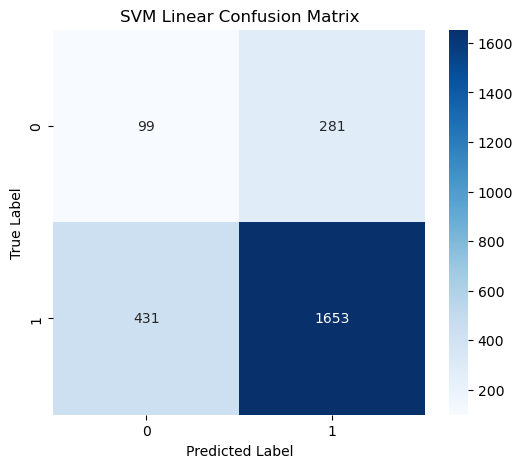

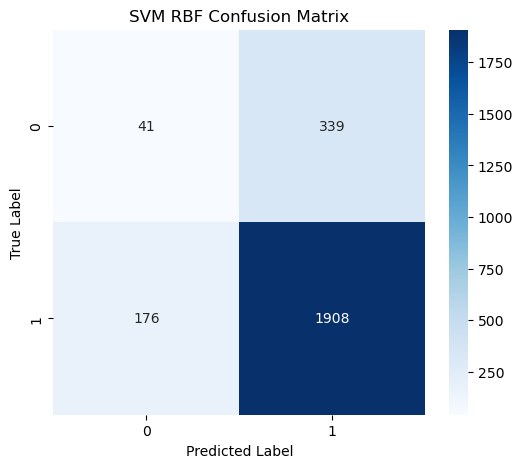

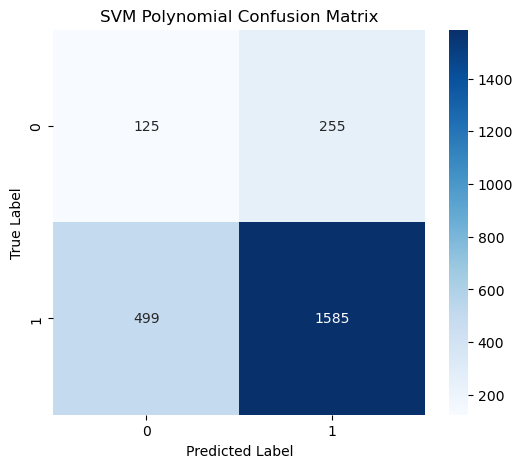

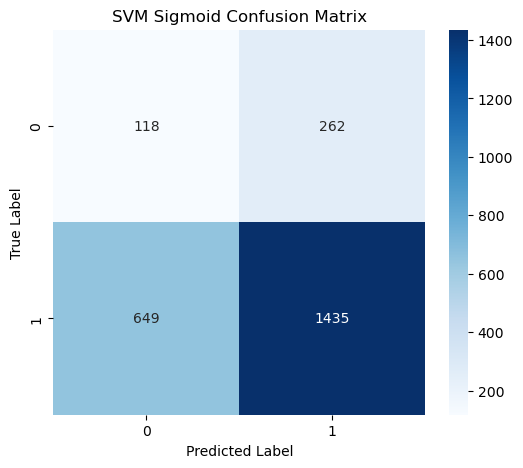

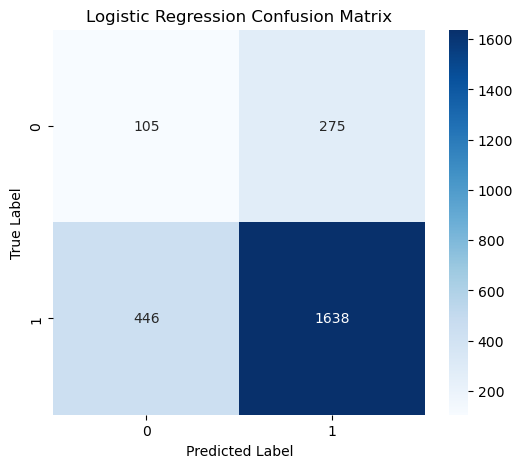

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Dictionary of models
models = {
    "SVM Linear": svm_linear,
    "SVM RBF": svm_rbf,
    "SVM Polynomial": svm_poly,
    "SVM Sigmoid": svm_sigmoid,
    "Logistic Regression": lr
}

# Generate confusion matrix heatmap for each model
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()